In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# load dataset

In [5]:
train = pd.read_csv("datasets/train.csv")

In [6]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,target
0,236,488,16,221,382,97,-4.472136,0.107472,0,132,...,13.340874,0.870542,1.962937,7.466666,11.547794,8.822916,9.046424,7.895535,11.010677,20.107472
1,386,206,357,232,1,198,7.810250,0.763713,1,143,...,12.484882,7.168680,2.885415,12.413973,10.260494,10.091351,9.270888,3.173994,13.921871,61.763713
2,429,49,481,111,111,146,8.602325,0.651162,1,430,...,14.030257,0.394970,8.160625,12.592059,8.937577,2.265191,11.255721,12.794841,12.080951,74.651162
3,414,350,481,370,208,158,8.306624,0.424645,1,340,...,2.789577,6.416708,10.549814,11.456437,6.468099,2.519049,0.258284,9.317696,5.383098,69.424645
4,318,359,20,218,317,301,8.124038,0.767304,1,212,...,1.886560,1.919999,2.268203,0.149421,4.105907,10.416291,6.816217,8.586960,4.512419,66.767304


In [7]:
train.shape

(90000, 54)

# basic checks

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       90000 non-null  int64  
 1   1       90000 non-null  int64  
 2   2       90000 non-null  int64  
 3   3       90000 non-null  int64  
 4   4       90000 non-null  int64  
 5   5       90000 non-null  int64  
 6   6       90000 non-null  float64
 7   7       90000 non-null  float64
 8   8       90000 non-null  int64  
 9   9       90000 non-null  int64  
 10  10      90000 non-null  int64  
 11  11      90000 non-null  int64  
 12  12      90000 non-null  int64  
 13  13      90000 non-null  float64
 14  14      90000 non-null  float64
 15  15      90000 non-null  float64
 16  16      90000 non-null  float64
 17  17      90000 non-null  float64
 18  18      90000 non-null  float64
 19  19      90000 non-null  float64
 20  20      90000 non-null  float64
 21  21      90000 non-null  float64
 22  22      9

In [9]:
train.describe()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,target
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,...,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,249.423944,250.236267,248.637289,249.736600,249.436178,249.656167,-0.011402,0.498548,0.499189,249.842033,...,7.475155,7.523962,7.508397,7.473322,7.490658,7.474578,7.509206,7.487159,7.513316,50.033981
std,144.336393,144.022200,144.107577,144.284945,143.941581,144.329168,7.038171,0.288682,0.500002,144.612718,...,4.330410,4.321537,4.331761,4.335692,4.332122,4.323035,4.326364,4.324876,4.333080,28.897243
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.949874,0.000014,0.000000,0.000000,...,0.000019,0.000040,0.000154,0.000083,0.000367,0.000014,0.000160,0.000147,0.000125,0.002634
25%,125.000000,126.000000,124.000000,125.000000,125.000000,124.000000,-7.071068,0.248932,0.000000,124.000000,...,3.707544,3.797002,3.760627,3.715721,3.739358,3.715298,3.773381,3.743536,3.776322,25.091903
50%,250.000000,251.000000,248.000000,250.000000,250.000000,250.000000,0.000000,0.497136,0.000000,250.000000,...,7.474127,7.533987,7.505259,7.459774,7.494167,7.477270,7.512575,7.476564,7.506812,50.030705
75%,374.000000,375.000000,374.000000,375.000000,373.000000,374.000000,7.000000,0.747513,1.000000,376.000000,...,11.216585,11.276349,11.261971,11.215637,11.239232,11.210070,11.268156,11.234414,11.277835,75.059454
max,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,9.949874,0.999987,1.000000,499.000000,...,14.999900,14.999528,14.999733,14.999478,14.999869,14.999928,14.999948,14.999364,14.999775,99.999482


In [10]:
missing = train.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [11]:
train.duplicated().sum()

np.int64(0)

# more detailed feature checks

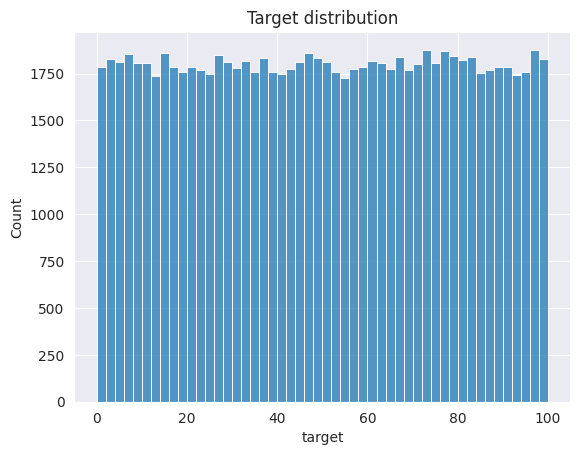

In [12]:
sns.histplot(train["target"], bins=50)
plt.title("Target distribution")
plt.show()

In [13]:
train["target"].describe()

count    90000.000000
mean        50.033981
std         28.897243
min          0.002634
25%         25.091903
50%         50.030705
75%         75.059454
max         99.999482
Name: target, dtype: float64

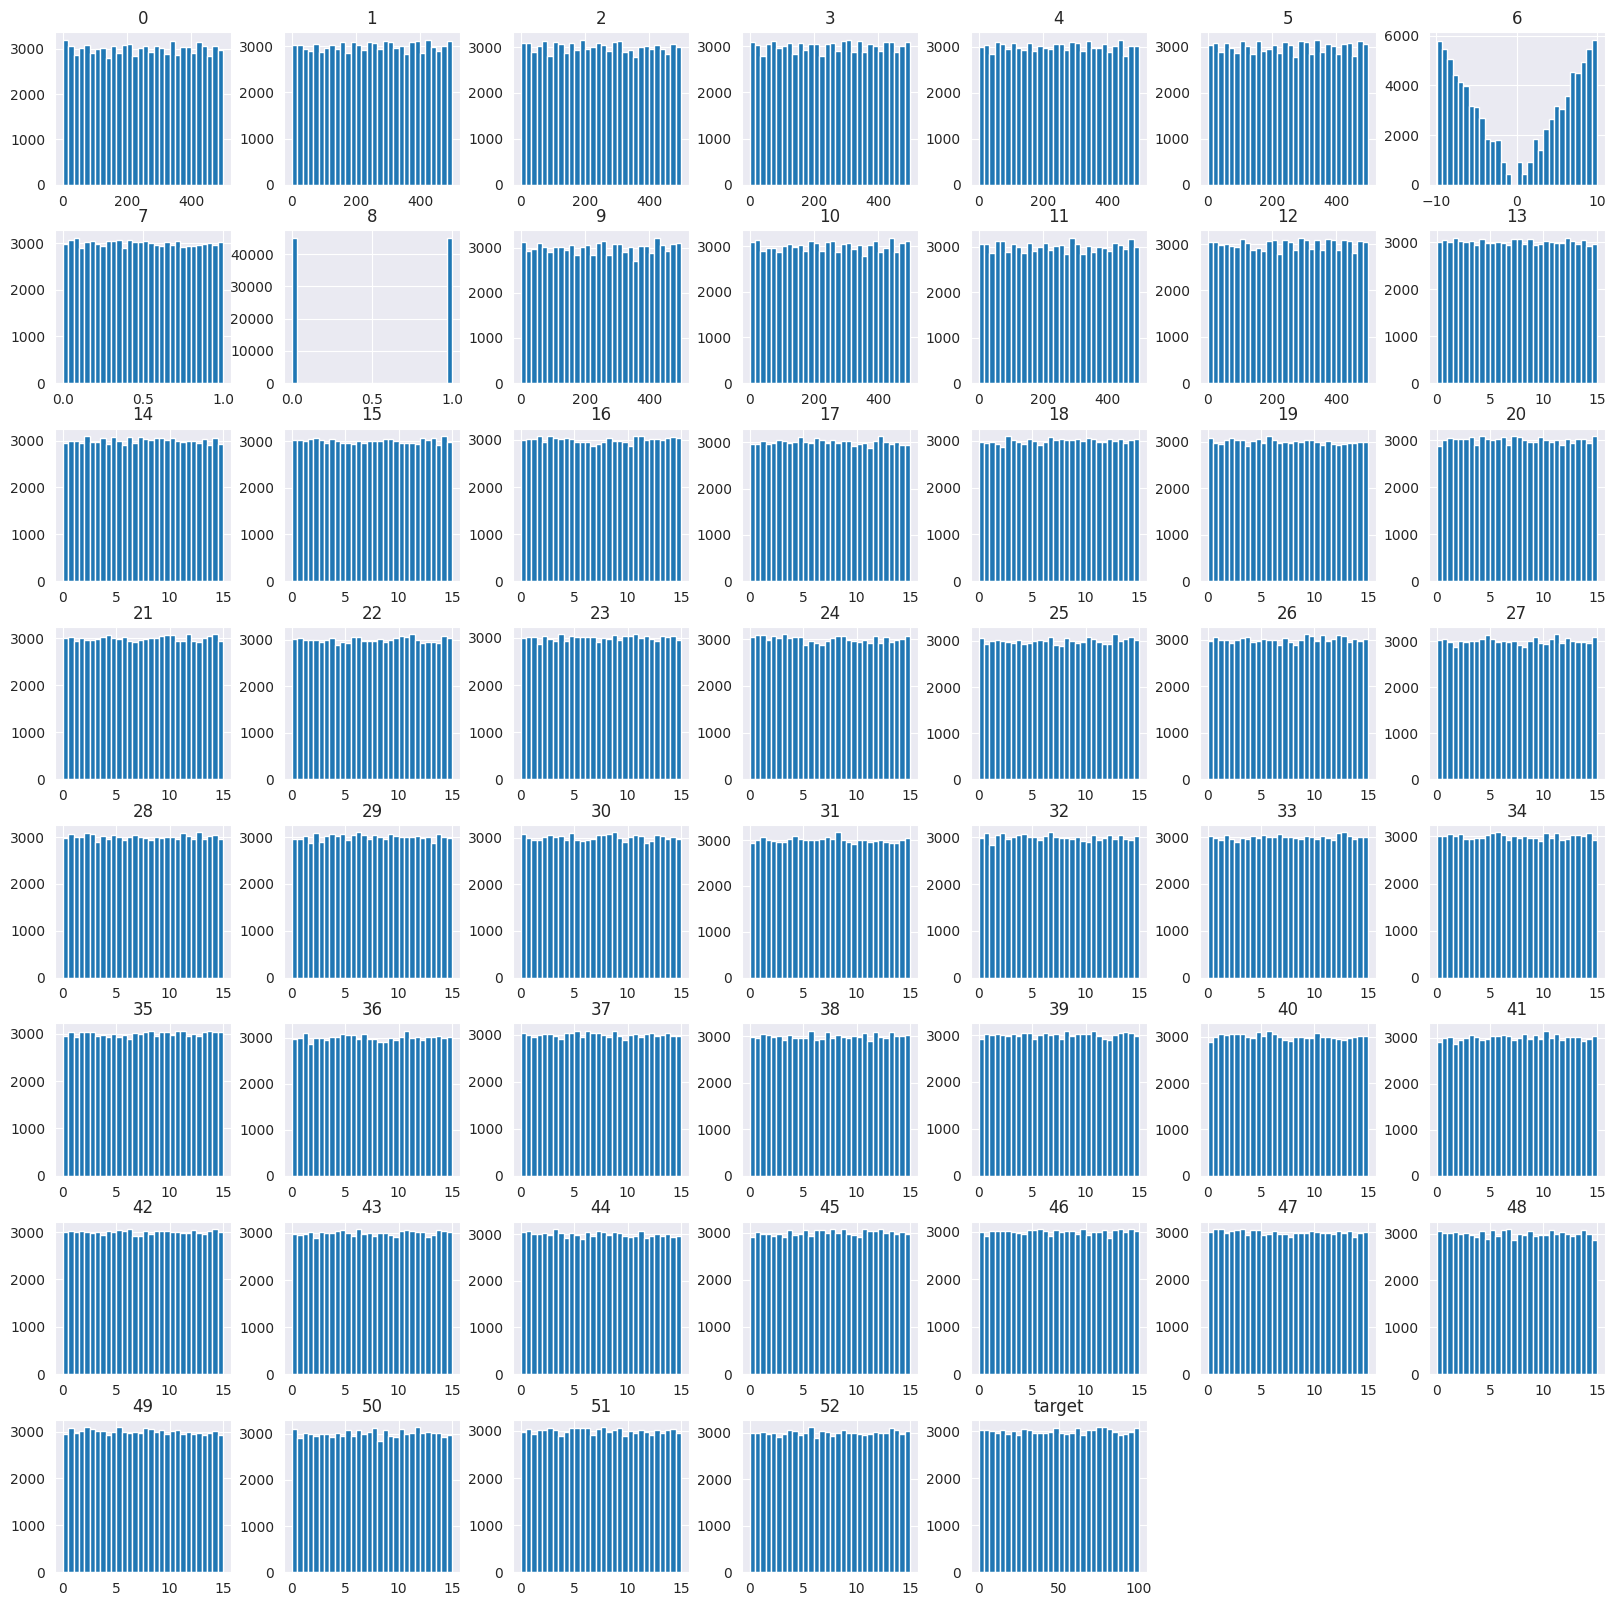

In [14]:
train.hist(
    bins=30,
    figsize=(20,20)
)

plt.show()

In [15]:
corr = (
    train
    .corr(numeric_only=True)["target"]
    .drop('target').sort_values()
)

In [16]:
corr.tail(10)

21    0.002874
17    0.002953
44    0.003092
10    0.003396
28    0.003451
25    0.004276
31    0.005077
39    0.006283
26    0.006370
7     0.012103
Name: target, dtype: float64

In [17]:
corr.head(10)

40   -0.007216
35   -0.006267
1    -0.005545
50   -0.005243
29   -0.004785
51   -0.004507
38   -0.003845
41   -0.003770
42   -0.002876
33   -0.002301
Name: target, dtype: float64

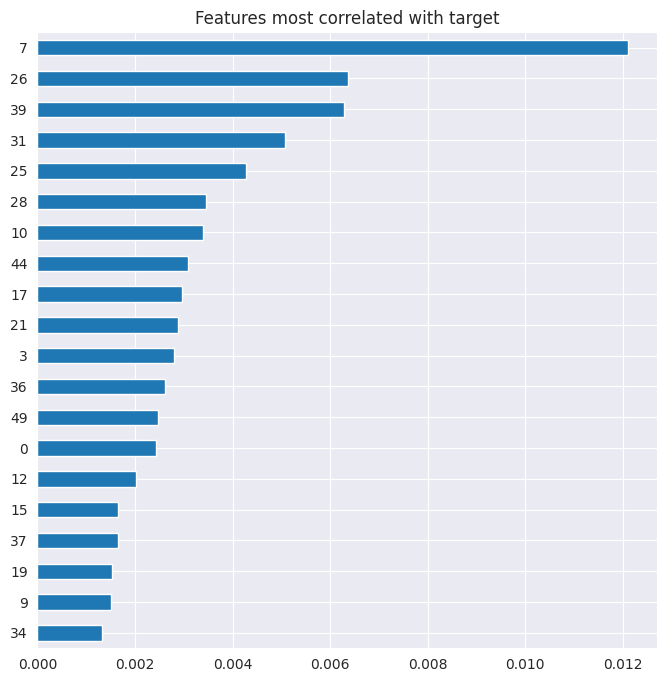

In [18]:
plt.figure(figsize=(8,8))

corr.tail(20).plot(kind="barh")

plt.title("Features most correlated with target")
plt.show()

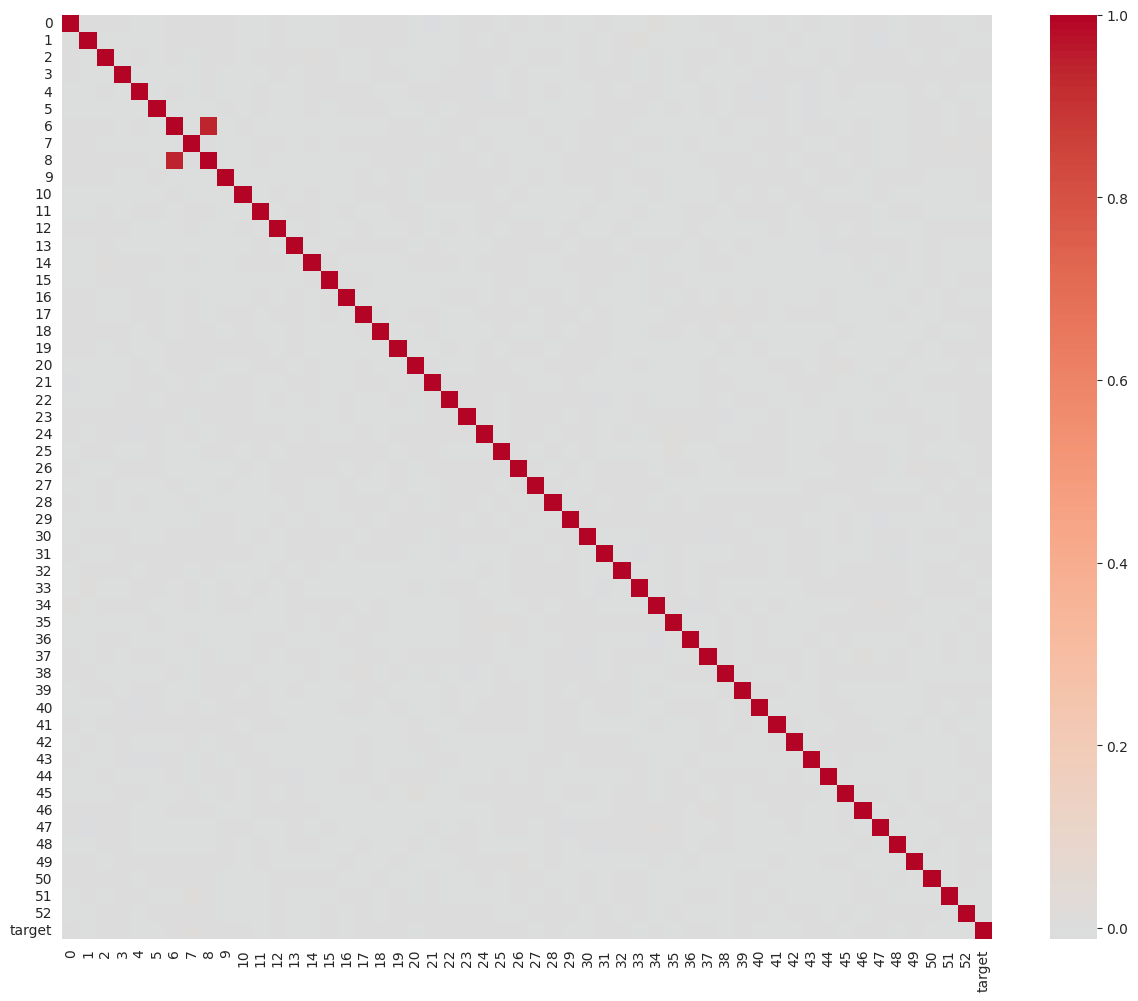

In [19]:
plt.figure(figsize=(15,12))

sns.heatmap(
    train.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.show()

# initial training

In [20]:
X = train.drop(columns=["target"])
y = train["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

preds = lr.predict(X_val)

rmse_lr = root_mean_squared_error(y_val, preds)

In [22]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_val)

rmse_rf = root_mean_squared_error(y_val, preds)

In [23]:
hgb = HistGradientBoostingRegressor(
    random_state=42
)

hgb.fit(X_train, y_train)

preds = hgb.predict(X_val)

rmse_hgb = root_mean_squared_error(y_val, preds)

# detailed results check

In [24]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_hgb
    ]
})

results.sort_values("RMSE")

,Model,RMSE
1,Random Forest,0.003733
2,HistGradientBoosting,0.021808
0,Linear Regression,29.015413


In [25]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

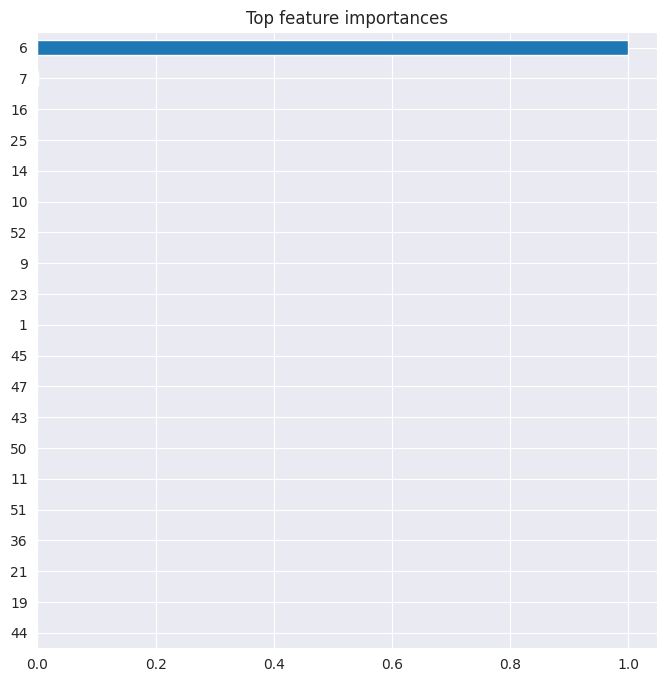

In [26]:
plt.figure(figsize=(8,8))

importance.tail(20).plot(kind="barh")

plt.title("Top feature importances")

plt.show()

### feature 6 looks strange, looks like its related to a result non-linearly, need to investigate

In [27]:
train['6'].describe()

count    90000.000000
mean        -0.011402
std          7.038171
min         -9.949874
25%         -7.071068
50%          0.000000
75%          7.000000
max          9.949874
Name: 6, dtype: float64

In [28]:
train['6'].value_counts().head(50)

6
-0.000000    903
-8.831761    527
-8.544004    523
-1.414214    507
 9.949874    504
 2.645751    501
 5.291503    490
-5.656854    489
-9.110434    484
 3.162278    481
-6.782330    481
 4.690416    480
 9.848858    480
 8.124038    479
 8.774964    479
-8.717798    478
-6.244998    478
 7.874008    477
-9.380832    476
-5.567764    476
 2.828427    476
-5.099020    475
-3.872983    474
 6.855655    474
 9.273618    474
-8.602325    473
 6.000000    472
-9.848858    471
-9.539392    470
-5.000000    470
 5.830952    469
-5.196152    469
-6.928203    469
-9.643651    468
-7.810250    468
-2.449490    468
 6.708204    467
 3.741657    467
-2.236068    466
-9.797959    465
-9.000000    464
 9.380832    464
 8.602325    463
 3.872983    463
-4.123106    463
 2.000000    463
-8.426150    462
-4.582576    462
 8.544004    462
-8.485281    462
Name: count, dtype: int64

In [29]:
train[['6', "target"]].corr()

,6,target
6,1.000000,0.000666
target,0.000666,1.000000


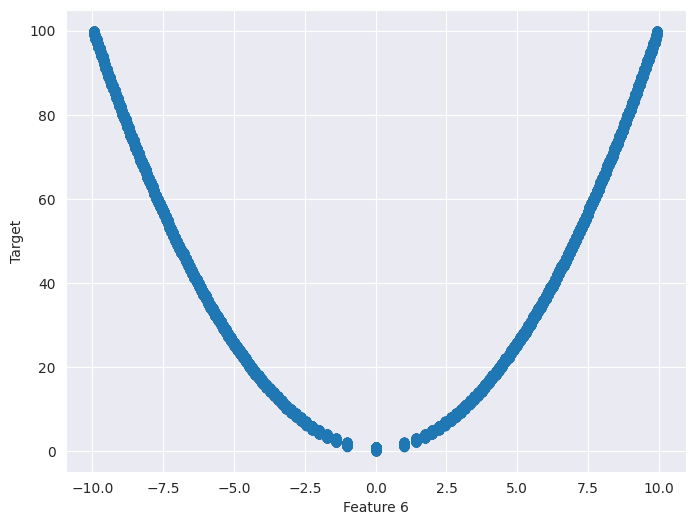

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(train['6'], train["target"], alpha=0.3)
plt.xlabel("Feature 6")
plt.ylabel("Target")
plt.show()

In [31]:

((train['6'] ** 2) - train['target']).describe()

count    90000.000000
mean        -0.498548
std          0.288682
min         -0.999987
25%         -0.747513
50%         -0.497136
75%         -0.248932
max         -0.000014
dtype: float64

In [32]:
pred = X_val['6'] ** 2

rmse = root_mean_squared_error(y_val, pred)

print(rmse)

0.5757013225091048


In [33]:
np.corrcoef(train["6"]**2, train["target"])

array([[1.       , 0.9999501],
       [0.9999501, 1.       ]])

### Feature 6 exhibits an almost deterministic nonlinear relationship with the target, suggesting possible target leakage or engineered dependency. I will continue using it because its almost determines the answer of a training task, but in prod models thats a bad idea

# remove feature and restart initial training

In [34]:
X_train = X_train.drop('6', axis=1)
X_val = X_val.drop('6', axis=1)

In [35]:
lr = LinearRegression()

lr.fit(X_train, y_train)

preds = lr.predict(X_val)

rmse_lr = root_mean_squared_error(y_val, preds)

In [36]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_val)

rmse_rf = root_mean_squared_error(y_val, preds)

In [37]:
hgb = HistGradientBoostingRegressor(
    random_state=42
)

hgb.fit(X_train, y_train)

preds = hgb.predict(X_val)

rmse_hgb = root_mean_squared_error(y_val, preds)

In [38]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_hgb
    ]
})

results.sort_values("RMSE")

,Model,RMSE
2,HistGradientBoosting,29.014665
0,Linear Regression,29.015043
1,Random Forest,29.096951


### HGB performed the best so we check additional stats

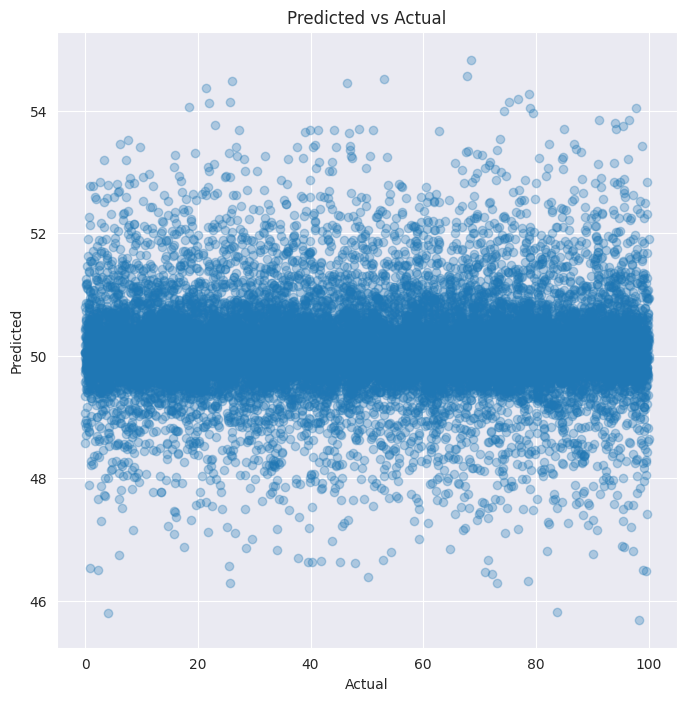

In [39]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_val,
    preds,
    alpha=0.3
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

plt.show()

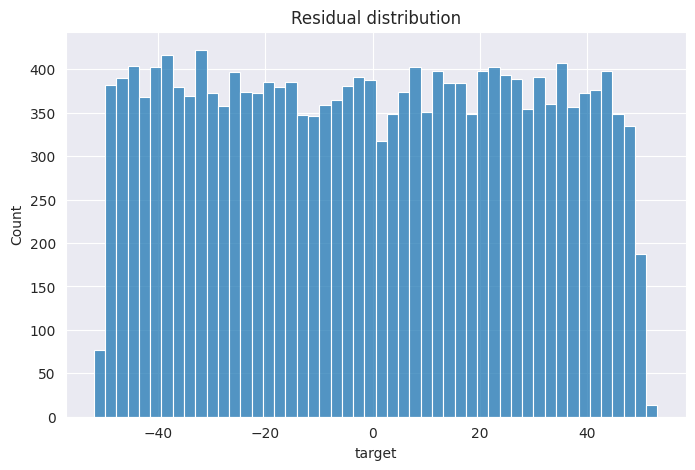

In [40]:
residuals = y_val - preds

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50)
plt.title("Residual distribution")
plt.show()

In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

print("RMSE:", root_mean_squared_error(y_val, preds))
print("MAE :", mean_absolute_error(y_val, preds))
print("R²  :", r2_score(y_val, preds))

RMSE: 29.01466498976473
MAE : 25.200846847387385
R²  : -0.001012559515825684


In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    hgb,
    X_val,
    y_val,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE :", rmse_scores.std())

Mean RMSE: 29.041470683994923
Std RMSE : 0.17737711536856993


In [43]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    hgb,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(
    perm.importances_mean,
    index=X_val.columns
).sort_values()

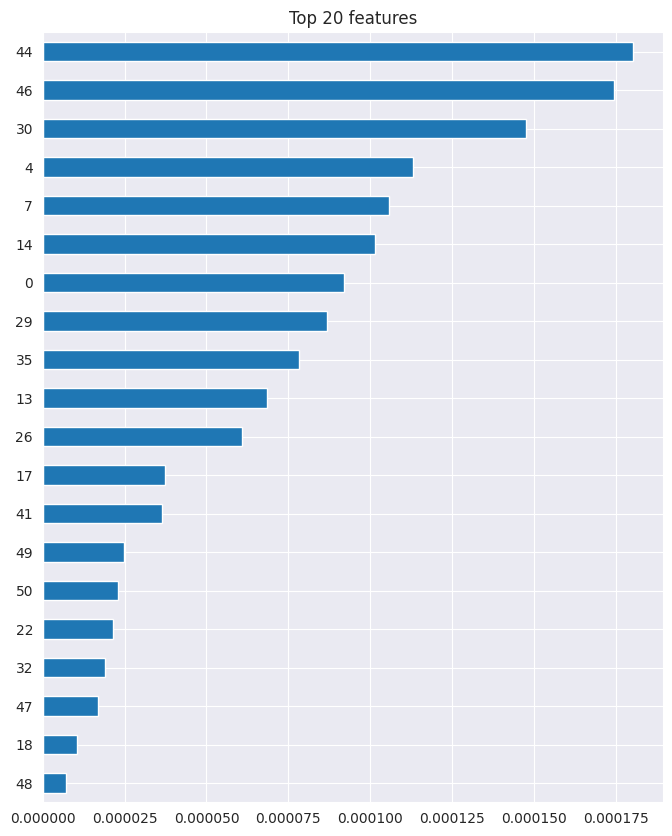

In [44]:
plt.figure(figsize=(8,10))

importance.tail(20).plot(kind="barh")

plt.title("Top 20 features")

plt.show()

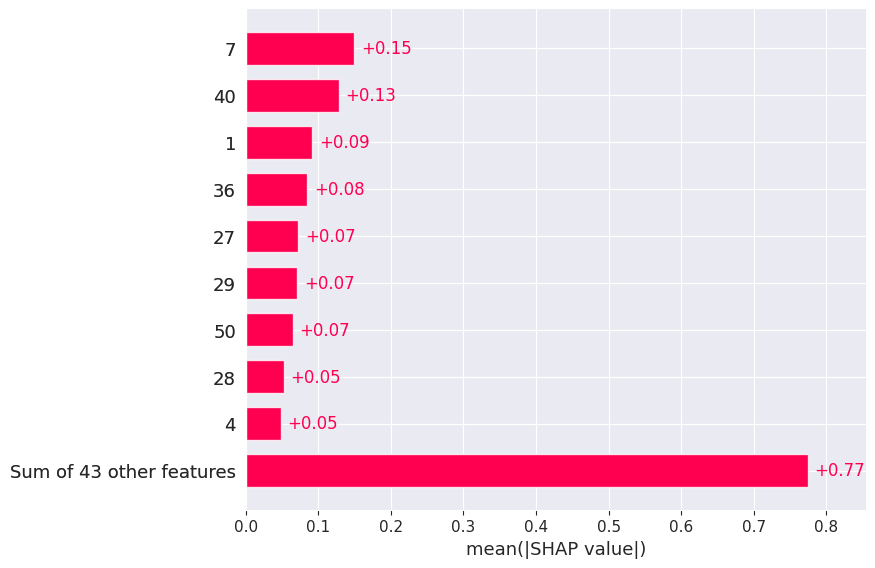

In [45]:
import shap

explainer = shap.Explainer(hgb)
shap_values = explainer(X_val)

shap.plots.bar(shap_values)

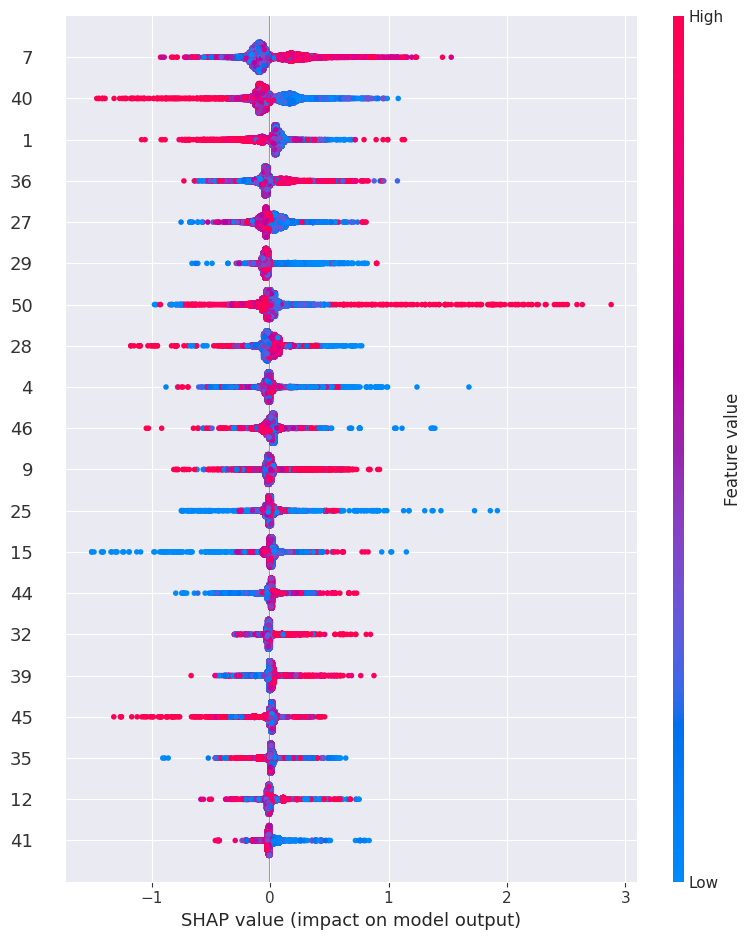

In [46]:
shap.summary_plot(
    shap_values,
    X_val
)

### After analyzing results i suppose that without feature 6 models just predicts means

In [47]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

dummy = DummyRegressor(strategy="mean")

scores = cross_val_score(
    dummy,
    X_val,
    y_val,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -scores

print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE :", rmse_scores.std())

Mean RMSE: 29.00107576431883
Std RMSE : 0.17690243325383745


### dummy regressor performed with similar stats, so deleting feature 6 was a mistake because it had almost all the useful information about target